<a href="https://colab.research.google.com/github/RithwikMohan/DeepLearning/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
puneet6060_intel_image_classification_path = kagglehub.dataset_download('puneet6060/intel-image-classification')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


**1. MLP — Vary Learning Rate & Plot Loss vs LR**

Downloaded path: /kaggle/input/datasets/puneet6060/intel-image-classification
Training directory: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Contents of train_dir: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Loaded 3000 images, skipped 0 files.
X shape: (3000, 3072)
y shape: (3000,)
Training with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training with learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training with learning rate = 0.01
Training with learning rate = 0.1


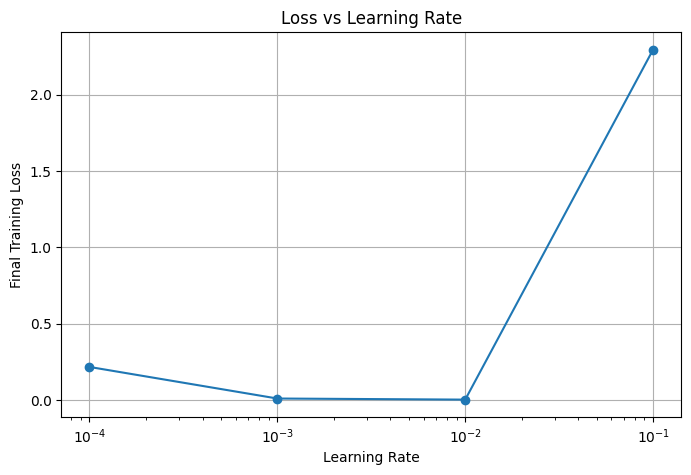

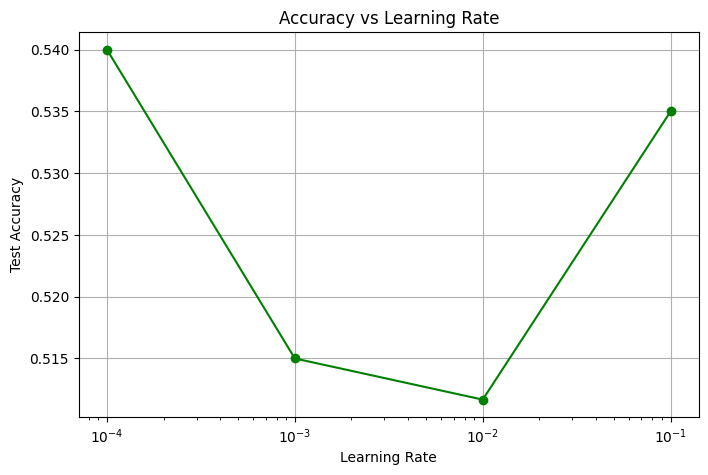

Learning Rate: 0.0001, Loss: 0.2154, Accuracy: 0.5400
Learning Rate: 0.001, Loss: 0.0085, Accuracy: 0.5150
Learning Rate: 0.01, Loss: 0.0013, Accuracy: 0.5117
Learning Rate: 0.1, Loss: 2.2945, Accuracy: 0.5350


In [ ]:
import kagglehub
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Download the Intel image dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Downloaded path:", path)

# Intel dataset structure is usually:
# path/seg_train/seg_train/buildings, forest, glacier, etc.
train_dir = os.path.join(path, "seg_train", "seg_train")

if not os.path.exists(train_dir):
    print("Falling back to simple seg_train layout")
    train_dir = os.path.join(path, "seg_train")

print("Training directory:", train_dir)

if not os.path.isdir(train_dir):
    raise NotADirectoryError(f"'{train_dir}' is not a directory. Check dataset layout.")

# Check contents
print("Contents of train_dir:", os.listdir(train_dir))

# Load classes (subfolders under train_dir)
classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])
print("Classes:", classes)

data = []
labels = []
n_skipped = 0
n_loaded = 0

# For each class
for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    count = 0  # limit per class

    if not os.path.isdir(folder):
        continue

    for img_name in os.listdir(folder):
        if count >= 500:  # limit per class for speed
            break

        # Only consider common image extensions
        if not any(img_name.lower().endswith(ext) for ext in [".jpg", ".jpeg", ".png"]):
            n_skipped += 1
            continue

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            n_skipped += 1
            print(f"Skipped unreadable image: {img_path}")
            continue

        # Resize to 32x32 and flatten
        img = cv2.resize(img, (32, 32))
        data.append(img.flatten())
        labels.append(i)
        count += 1
        n_loaded += 1

print(f"Loaded {n_loaded} images, skipped {n_skipped} files.")

# Convert to arrays
X = np.array(data)
y = np.array(labels)

# Bail early if no data
if X.shape[0] == 0:
    raise ValueError("No valid images loaded; X is empty. Check dataset path and file formats.")

print("X shape:", X.shape)   # should be (N, 3072)
print("y shape:", y.shape)   # should be (N,)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Try different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []
accuracies = []

for lr in learning_rates:
    print(f"Training with learning rate = {lr}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        learning_rate_init=lr,
        max_iter=50,
        random_state=42,
        verbose=False
    )

    mlp.fit(X_train, y_train)
    losses.append(mlp.loss_)
    accuracies.append(mlp.score(X_test, y_test))

# Plot Loss vs Learning Rate
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Training Loss")
plt.title("Loss vs Learning Rate")
plt.grid(True)
plt.show()

# Plot Accuracy vs Learning Rate
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, accuracies, marker='o', color='green')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Learning Rate")
plt.grid(True)
plt.show()

# Print results
for lr, loss, acc in zip(learning_rates, losses, accuracies):
    print(f"Learning Rate: {lr}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

**MLP using Gradient Descent (Convergence Analysis)**

Iteration 1, loss = 1.91568811
Iteration 2, loss = 1.49025168
Iteration 3, loss = 1.31571894
Iteration 4, loss = 1.23062869
Iteration 5, loss = 1.16294608
Iteration 6, loss = 1.10927598
Iteration 7, loss = 1.06436417
Iteration 8, loss = 1.02669522
Iteration 9, loss = 0.99111432
Iteration 10, loss = 0.95822556
Iteration 11, loss = 0.92882866
Iteration 12, loss = 0.90212236
Iteration 13, loss = 0.87588105
Iteration 14, loss = 0.85117218
Iteration 15, loss = 0.82834822
Iteration 16, loss = 0.80686552
Iteration 17, loss = 0.78665830
Iteration 18, loss = 0.76728251
Iteration 19, loss = 0.74837322
Iteration 20, loss = 0.73003786
Iteration 21, loss = 0.71364759
Iteration 22, loss = 0.69622504
Iteration 23, loss = 0.68030177
Iteration 24, loss = 0.66619499
Iteration 25, loss = 0.65132590
Iteration 26, loss = 0.63548597
Iteration 27, loss = 0.62240626
Iteration 28, loss = 0.60882262
Iteration 29, loss = 0.59727470
Iteration 30, loss = 0.58324324
Iteration 31, loss = 0.57191134
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


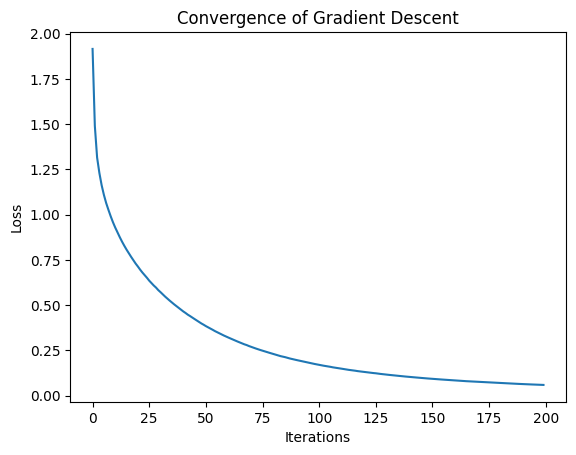

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    learning_rate_init=0.001,
    max_iter=200,
    solver='sgd',   # Gradient Descent
    verbose=True
)

mlp.fit(X_train, y_train)

plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence of Gradient Descent")
plt.show()

MLP on Any Dataset (Parameter Tuning)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    learning_rate_init=0.001,
    max_iter=100
)

mlp.fit(X_train, y_train)

print("Accuracy:", mlp.score(X_test, y_test))

Accuracy: 0.5383333333333333


MLP (XOR) with ALL Optimizers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Activation
def sigmoid(x): return 1/(1+np.exp(-x))
def sigmoid_deriv(x): return x*(1-x)

# Initialize
def init_params():
    np.random.seed(0)
    W1 = np.random.randn(2,4)
    b1 = np.zeros((1,4))
    W2 = np.random.randn(4,1)
    b2 = np.zeros((1,1))
    return W1,b1,W2,b2

# Forward
def forward(X,W1,b1,W2,b2):
    a1 = sigmoid(X @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)
    return a1,a2

# Loss
def compute_loss(y,y_pred):
    return np.mean((y-y_pred)**2)

Training Function (ALL Optimizers)

In [ ]:
def train(optimizer, lr=0.1, epochs=1000, batch_size=2):
    W1,b1,W2,b2 = init_params()

    # optimizer states
    vW1=vW2=0; mW1=mW2=0; sW1=sW2=0
    eps=1e-8; beta=0.9; beta1=0.9; beta2=0.999

    losses=[]

    for epoch in range(epochs):
        if optimizer=="BGD":
            X_batch, y_batch = X, y
        elif optimizer=="SGD":
            idx = np.random.randint(0,4)
            X_batch, y_batch = X[idx:idx+1], y[idx:idx+1]
        else:  # Mini-batch
            idx = np.random.choice(4,batch_size)
            X_batch, y_batch = X[idx], y[idx]

        a1,a2 = forward(X_batch,W1,b1,W2,b2)

        # backprop
        dz2 = (a2-y_batch)*sigmoid_deriv(a2)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2,axis=0)

        dz1 = dz2 @ W2.T * sigmoid_deriv(a1)
        dW1 = X_batch.T @ dz1
        db1 = np.sum(dz1,axis=0)

        # OPTIMIZERS
        if optimizer in ["BGD","SGD","MiniBatch"]:
            W1 -= lr*dW1; W2 -= lr*dW2

        elif optimizer=="Momentum":
            vW1 = beta*vW1 + (1-beta)*dW1
            W1 -= lr*vW1

        elif optimizer=="Nesterov":
            temp = W1 - beta*vW1
            vW1 = beta*vW1 + (1-beta)*dW1
            W1 -= lr*vW1

        elif optimizer=="Adagrad":
            sW1 += dW1**2
            W1 -= lr/(np.sqrt(sW1)+eps)*dW1

        elif optimizer=="RMSProp":
            sW1 = 0.9*sW1 + 0.1*(dW1**2)
            W1 -= lr/(np.sqrt(sW1)+eps)*dW1

        elif optimizer=="Adadelta":
            sW1 = 0.9*sW1 + 0.1*(dW1**2)
            update = -np.sqrt(sW1+eps)*dW1
            W1 += update

        elif optimizer=="Adam":
            mW1 = beta1*mW1 + (1-beta1)*dW1
            sW1 = beta2*sW1 + (1-beta2)*(dW1**2)
            m_hat = mW1/(1-beta1)
            v_hat = sW1/(1-beta2)
            W1 -= lr*m_hat/(np.sqrt(v_hat)+eps)

        # loss
        _,pred = forward(X,W1,b1,W2,b2)
        losses.append(compute_loss(y,pred))

    return losses

Run & Compare

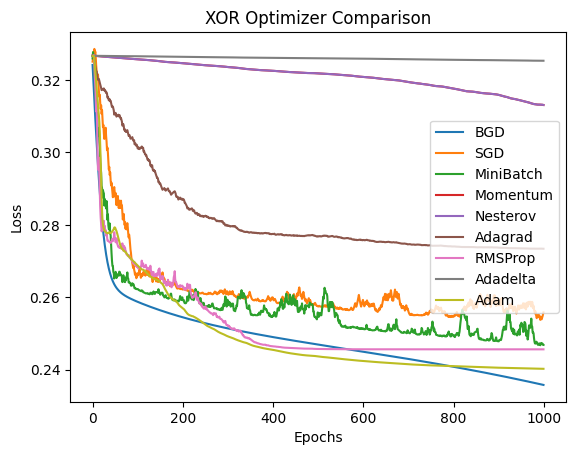

In [ ]:
optimizers = ["BGD","SGD","MiniBatch","Momentum","Nesterov","Adagrad","RMSProp","Adadelta","Adam"]

for opt in optimizers:
    loss = train(opt)
    plt.plot(loss,label=opt)

plt.legend()
plt.title("XOR Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Applying on Intel Image classification dataset

In [ ]:
import kagglehub
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

data, labels = [], []

# Intel layout: path -> seg_train -> seg_train -> classes
base = path + "/seg_train/seg_train"
if not os.path.exists(base):
    base = path + "/seg_train"

classes = sorted([
    cls for cls in os.listdir(base)
    if os.path.isdir(os.path.join(base, cls))
])
print("Classes:", classes)

n_skipped = 0
n_loaded = 0

for i, cls in enumerate(classes):
    folder = os.path.join(base, cls)
    count = 0

    for img_name in os.listdir(folder):
        if count >= 300:  # limit per class
            break

        # Only process valid image files
        ext = img_name.lower()
        if not (ext.endswith(".jpg") or ext.endswith(".jpeg") or ext.endswith(".png")):
            n_skipped += 1
            continue

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            n_skipped += 1
            print(f"Skipped unreadable image: {img_path}")
            continue

        img = cv2.resize(img, (32, 32))
        data.append(img.flatten())
        labels.append(i)
        count += 1
        n_loaded += 1

print(f"Loaded {n_loaded} images, skipped {n_skipped} files.")

X = np.array(data)
y = np.array(labels)

# If X is empty now, bail early
if X.shape[0] == 0:
    raise ValueError("No valid images loaded; X is empty.")

print("X shape:", X.shape)
print("y shape:", y.shape)

# normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Loaded 1800 images, skipped 0 files.
X shape: (1800, 3072)
y shape: (1800,)


In [ ]:
results = {}

optimizers = ["sgd","adam"]

for opt in optimizers:
    model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        solver=opt,
        learning_rate_init=0.001,
        max_iter=50
    )
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    results[opt] = acc

print(results)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


{'sgd': 0.5472222222222223, 'adam': 0.5388888888888889}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


**WEEK 5**

2026-04-12 17:12:12.886492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776013933.152233      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776013933.233170      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776013933.867404      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776013933.867472      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776013933.867476      55 computation_placer.cc:177] computation placer alr

Downloaded path: /kaggle/input/datasets/puneet6060/intel-image-classification
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


2026-04-12 17:12:46.220362: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Batch shape: (32, 128, 128, 3)
Label shape: (32,)


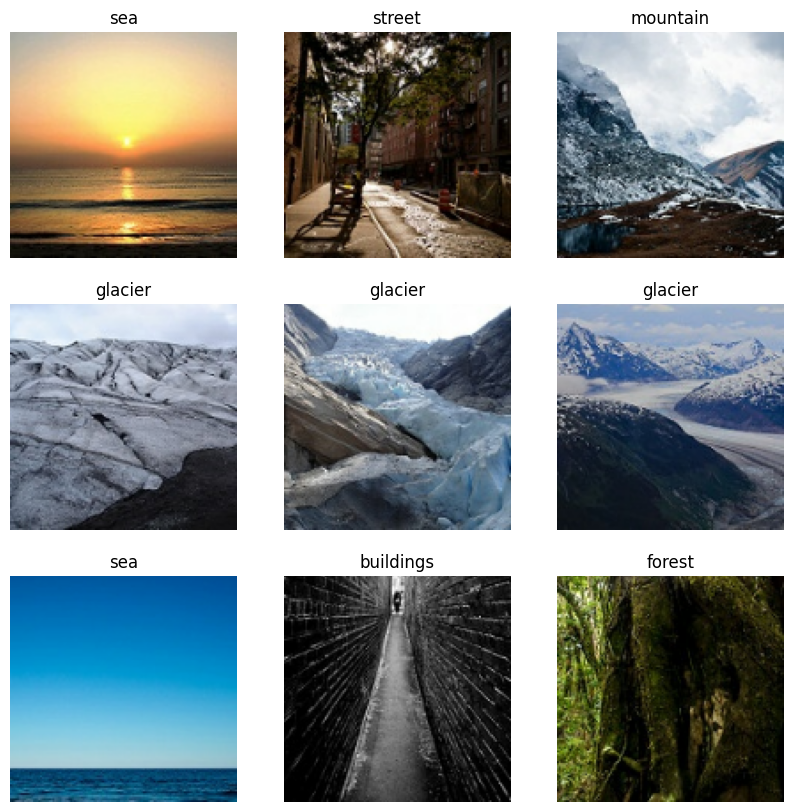

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 500ms/step - accuracy: 0.3345 - loss: 1.5111 - val_accuracy: 0.5132 - val_loss: 1.1171
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 502ms/step - accuracy: 0.4825 - loss: 1.1704 - val_accuracy: 0.5613 - val_loss: 1.0150
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 174s 496ms/step - accuracy: 0.5600 - loss: 1.0603 - val_accuracy: 0.5948 - val_loss: 0.9685
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 182s 518ms/step - accuracy: 0.5879 - loss: 0.9869 - val_accuracy: 0.6468 - val_loss: 0.8743
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 501ms/step - accuracy: 0.6610 - loss: 0.8768 - val_accuracy: 0.6686 - val_loss: 0.7834
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 514ms/step - accuracy: 0.6849 - loss: 0.8163 - val_accuracy: 0.6903 - val_loss: 0.8095
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 174s 496ms/step - accuracy: 0.7078 - loss: 0.7783 - val_accuracy: 0.7619 - val_loss: 0.6555
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 173s 493ms/step - accuracy: 0.7304 -

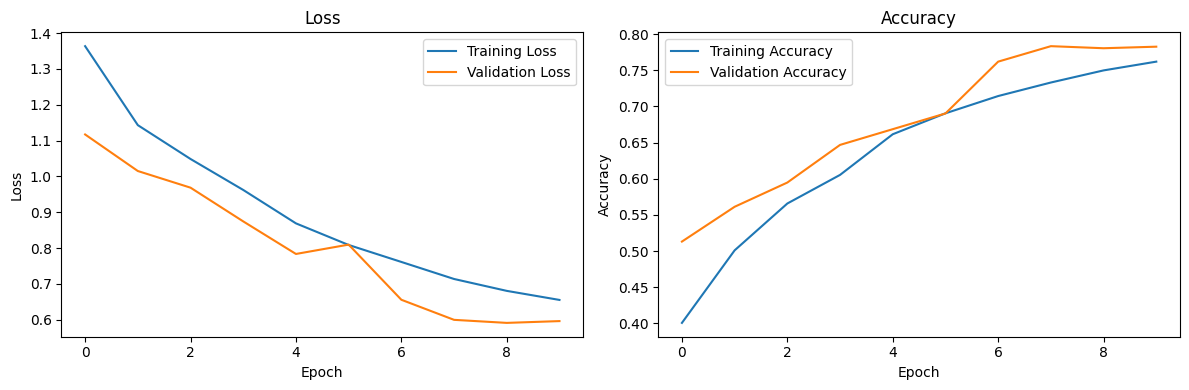

In [ ]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Downloaded path:", path)

# Correct train directory (Intel layout: seg_train/seg_train)
train_dir = path + "/seg_train/seg_train"

# Create train and validation datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Print some info
print("Train dataset:", train_ds)
print("Validation dataset:", val_ds)
print("Classes:", train_ds.class_names)

# Visualize one batch (optional, for your notebook)
class_names = train_ds.class_names

for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)    # (B, 128, 128, 3)
    print("Label shape:", labels.shape)    # (B,)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()
    break

# Build a simple CNN model
num_classes = len(train_ds.class_names)

model = tf.keras.Sequential([
    # Rescale to [0,1] (instead of 0–255)
    tf.keras.layers.Rescaling(1./255., input_shape=(128, 128, 3)),

    # Conv blocks
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense head
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

# Optional: plot loss and accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()